# Import

In [ ]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import numpy as np
import time
import time
from tqdm import tqdm
from selenium.webdriver.common.by import By


# Data Parsing from Verra open database

In [ ]:
projects = pd.read_csv("data/raw/registered.csv")

In [142]:
options = Options()
options.add_argument("--headless")  # если хочешь без GUI
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--no-sandbox")
options.add_argument("--disable-gpu")
options.add_argument("--disable-extensions")

# Создаём драйвер
driver = webdriver.Chrome(options=options)

There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache
Error sending stats to Plausible: error sending request for url (https://plausible.io/api/event)


In [62]:
projects['Link'] = projects['ID'].apply(lambda x: f"https://registry.verra.org/app/projectDetail/VCS/{x}")


In [ ]:
for i in tqdm(range(len(projects)), desc="Загрузка описаний проектов"):
    driver.get(projects.loc[i, 'Link'])
    time.sleep(15)  # ждём, пока страница загрузится
    
    try:
        # Находим элемент и вытаскиваем текст
        desc = driver.find_element(By.CSS_SELECTOR, ".card-text.p-3").text
        projects.loc[i, 'Description'] = desc
    except Exception as e:
        print(f"Ошибка при обработке {projects.loc[i, 'Link']}: {e}")
        projects.loc[i, 'Description'] = ""
        break

    if i%50 == 0:
        projects.to_csv("/Users/annakudryavtseva/Documents/ML + NBS project/data/processed/projects_with_descriptions.csv", index=False)


Загрузка описаний проектов: 100%|██████████| 1051/1051 [4:30:00<00:00, 15.41s/it] 


In [ ]:
projects.to_csv("data/processed/projects_with_descriptions.csv", index=False)


# Data Processing

In [ ]:
projects = pd.read_csv("data/processed/verra_projects_with_russian_description.csv")

In [84]:
projects.drop(['Status'], axis=1, inplace=True)

# Active versions of methodologies


In [ ]:
mapping = pd.read_csv("data/Methodology mapping.csv")

In [87]:
mapping = mapping.rename(columns={
    "Методология": "Methodology",
    "Статус в Verra": "Status",
    "Как используется / Замена": "Replacement"
})

In [ ]:
# Merge с projects 
projects = projects.merge(
    mapping[['Methodology', 'Status', 'Replacement']],
    how='left',
    on='Methodology'
)

In [ ]:
# 
def get_canonical_methodology(row):
    status = row['Status']
    replacement = row['Replacement']
    
    if pd.isna(status):
        return "Not applicable"
    
    if status in ['Active', 'Allowed via VMR']:
        return row['Methodology']
    
    elif "Replaced" in status:
        return replacement if pd.notna(replacement) else "Not applicable"
    
    else:
        return "Not applicable"

projects['Methodology_final'] = projects.apply(get_canonical_methodology, axis=1)

projects = projects[projects['Methodology_final'] != "Not applicable"]

print(projects['Methodology_final'].value_counts().head(15))
print("Всего уникальных методологий:", projects['Methodology_final'].nunique())

projects.to_csv("data/verra_projects_final.csv", index=False)



Methodology_final
ACM0002       661
AMS-I.D.      351
VMR0006       121
ACM0001       113
VM0047         86
AMS-II.G.      82
AMS-I.C.       72
AMS-III.D.     54
ACM0010        43
AMS-I.E.       39
ACM0008        34
ACM0006        31
ACM0022        28
ACM0012        27
AM0073         20
Name: count, dtype: int64
Всего уникальных методологий: 85


# TF-IDF

In [ ]:
print(projects.shape)
print(projects['Methodology_final'].nunique())
projects['Methodology_final'].value_counts().head(15)

In [ ]:
! pip install scikit-learn

In [103]:
method_counts = projects['Methodology_final'].value_counts()

MIN_SAMPLES = 10

valid_methods = method_counts[method_counts >= MIN_SAMPLES].index

projects['Methodology_ml'] = projects['Methodology_final'].where(
    projects['Methodology_final'].isin(valid_methods),
    'Other methodologies'
)


/var/folders/61/v9rtqvx96wbcfbzq8n1_nv940000gn/T/ipykernel_72487/2026713273.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projects['Methodology_ml'] = projects['Methodology_final'].where(


In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,   # ограничиваем размер словаря
    ngram_range=(1,2),   # uni- и bi-grams
    stop_words=None       # можно добавить список русских стоп-слов позднее
)

# обучаем на train
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF матрица train:", X_train_tfidf.shape)
print("TF-IDF матрица test:", X_test_tfidf.shape)


TF-IDF матрица train: (1649, 5000)
TF-IDF матрица test: (413, 5000)


In [ ]:
! pip install seaborn

In [122]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,   # ограничиваем размер словаря
    ngram_range=(1,2),   # uni- и bi-grams
    stop_words=None       # можно добавить список русских стоп-слов позднее
)

# обучаем на train
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF матрица train:", X_train_tfidf.shape)
print("TF-IDF матрица test:", X_test_tfidf.shape)

from sklearn.linear_model import LogisticRegression

# создаём модель
model = LogisticRegression(
    max_iter=1000,      # достаточно итераций
    solver='lbfgs',
    n_jobs=-1
)

# обучаем
model.fit(X_train_tfidf, y_train)

# предсказания на test
y_pred = model.predict(X_test_tfidf)



TF-IDF матрица train: (1649, 5000)
TF-IDF матрица test: (413, 5000)


/Users/annakudryavtseva/Documents/ML + NBS project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.726

Classification Report:

                     precision    recall  f1-score   support

            ACM0001       0.88      0.96      0.92        23
            ACM0002       0.66      0.88      0.75       132
            ACM0006       0.00      0.00      0.00         6
            ACM0008       1.00      0.86      0.92         7
            ACM0010       0.90      1.00      0.95         9
            ACM0012       1.00      0.60      0.75         5
            ACM0014       0.00      0.00      0.00         2
            ACM0022       1.00      0.33      0.50         6
             AM0029       0.00      0.00      0.00         3
             AM0073       1.00      0.75      0.86         4
           AMS-I.C.       0.85      0.73      0.79        15
           AMS-I.D.       0.61      0.47      0.53        70
           AMS-I.E.       1.00      0.75      0.86         8
           AMS-I.F.       1.00      0.33      0.50         3
          AMS-II.C.       0.00      0.00   

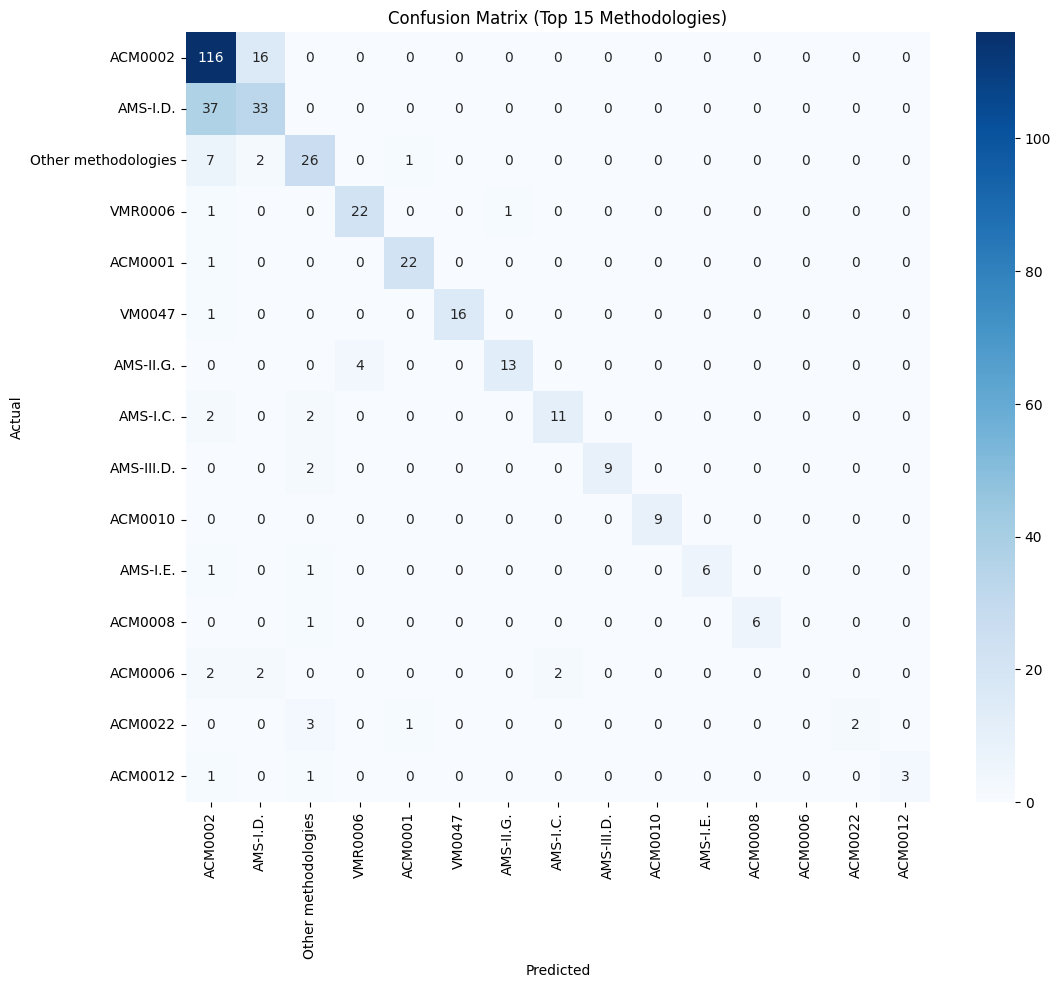

In [123]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix — для топ-15 методологий
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

top_labels = y_train.value_counts().head(15).index.tolist()
cm = confusion_matrix(y_test, y_pred, labels=top_labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=top_labels, yticklabels=top_labels, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Top 15 Methodologies)')
plt.show()


In [124]:
import joblib

joblib.dump(model, "models/logreg_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("Модель и TF-IDF сохранены в папке models/")


Модель и TF-IDF сохранены в папке models/


## Test of model

In [125]:
import joblib

model = joblib.load("models/logreg_model.pkl")
tfidf = joblib.load("models/tfidf_vectorizer.pkl")

print("Модель и TF-IDF загружены")


Модель и TF-IDF загружены


In [126]:
import pandas as pd
import numpy as np

def classify_project(text, model, tfidf, top_k=5):
    # TF-IDF преобразование
    X = tfidf.transform([text])
    
    # Основной класс
    pred_class = model.predict(X)[0]
    
    # Вероятности
    probs = model.predict_proba(X)[0]
    classes = model.classes_
    
    top = (
        pd.DataFrame({
            "Methodology": classes,
            "Probability": probs
        })
        .sort_values("Probability", ascending=False)
        .head(top_k)
    )
    
    return pred_class, top


In [127]:
test_description = """
Проект предусматривает строительство солнечной электростанции
мощностью 50 МВт. Производство электроэнергии из возобновляемых
источников позволяет заместить генерацию на ископаемом топливе
и сократить выбросы парниковых газов.
"""


In [128]:
pred, top_probs = classify_project(
    test_description,
    model=model,
    tfidf=tfidf,
    top_k=7
)

print("🔮 Предсказанная методология:", pred)
print("\nТоп вероятностей:")
display(top_probs)


🔮 Предсказанная методология: ACM0002

Топ вероятностей:


,Methodology,Probability
1,ACM0002,0.743753
11,AMS-I.D.,0.144838
20,Other methodologies,0.023496
0,ACM0001,0.007428
10,AMS-I.C.,0.007426
24,VMR0006,0.007050
2,ACM0006,0.005928


### sanity-check

In [130]:
sample = projects.sample(1, random_state=1).iloc[0]

print("Истинная методология:", sample['Methodology_ml'])
print("\nОписание проекта:\n")
print(sample['Rus Description'][:1000])


pred, top = classify_project(
    sample['Rus Description'],
    model,
    tfidf
)

print("\n🔮 Предсказанная методология:", pred)
display(top)


Истинная методология: ACM0001

Описание проекта:

Предлагаемый проект VCS под названием «Проект преобразования свалочного газа в энергию Meioeste UniCarbo» включает в себя содействие на полигоне Meioeste уничтожению и/или утилизации и/или поставке потребителям свалочного газа (свалочного газа, богатого метаном) путем сбора свалочного газа и его уничтожения в высокотемпературных закрытых открытых факельных установках, использования в качестве газообразного топлива в генераторных установках электрогенерирующей инфраструктуры (с общей установленной номинальной мощностью 5 МВт) и прогнозируемой поставки модернизированного свалочного газа потребителям с помощью инфраструктуры переработки и поставки свалочного газа с общей установленной мощностью 5000 Нм³/ч.

🔮 Предсказанная методология: ACM0001


,Methodology,Probability
0,ACM0001,0.871350
11,AMS-I.D.,0.025066
20,Other methodologies,0.020965
1,ACM0002,0.016168
22,VM0047,0.007091
